In [1]:
import numpy as np
import pandas as pd
import torch
from seaborn import kdeplot
from sbi.utils import get_kde, KDEWrapper, BoxUniform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore', Warning)

import sys
sys.path.insert(1, '../../collective_posterior/')
from collective_posterior import CollectivePosterior

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


low = torch.tensor([-4.6, 0.01, -1.39, 0.92, -9.2])
high = torch.tensor([1.61, 1, 1.39, 3.92, -1.2])
prior = BoxUniform(low=low, high=high)

change_font(16)

/home/jupyter-nadavbennun/.conda/envs/npse/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Text(-8.0, 0, '0.0'),
 Text(-6.0, 0, '0.002'),
 Text(-4.0, 0, '0.018'),
 Text(-2.0, 0, '0.135'),
 Text(0.0, 0, '1.0'),
 Text(2.0, 0, '7.389'),
 Text(4.0, 0, '54.598')]

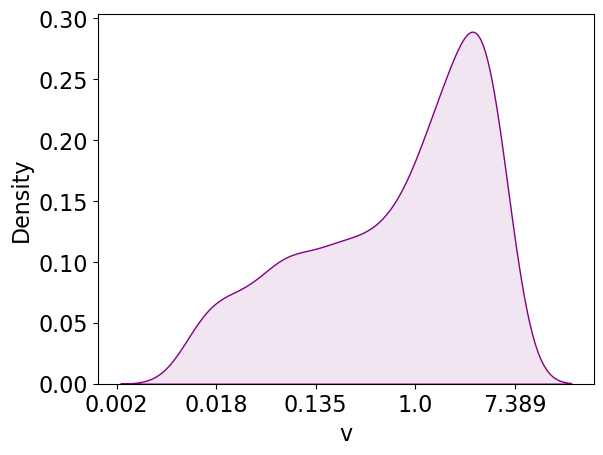

In [2]:
fig, ax = plt.subplots()
results_df = pd.read_csv('abcout13.csv', dtype='float')
y = results_df.iloc[:,6]
kdeplot(y, fill=True, color='purple', alpha=0.1)
ax.set_xticklabels([round(np.e**float(a),3) for a in ax.get_xticks()])
# ax.axvline(np.log(5), color='k', ls = '--')

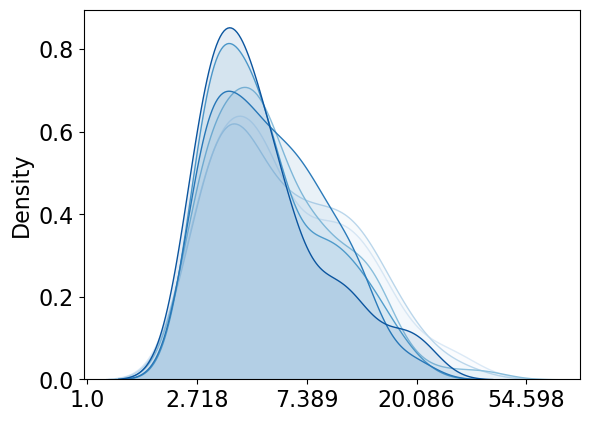

In [3]:
fig, ax = plt.subplots()
p = sns.color_palette("Blues", 6)
kdes = []
total_sims = pd.DataFrame()
for i in range(6):
    df_pop = results_df.iloc[:,12+10*i:22+10*i]
    df_pop.loc[:,'dist'] = (df_pop.iloc[:,-10:]**2).sum(1)
    eps = df_pop['dist'].quantile(0.1)
    df_pop = df_pop[df_pop['dist']<eps]
    k = results_df.iloc[df_pop.index, 6:11]
    total_sims = pd.concat([total_sims, k], axis=0)
    r = torch.tensor(np.array(k))
    kde = get_kde(r)
    kdes.append(kde)

    kdeplot(r[:,3], fill=True, alpha=0.1, ax=ax, color = p[i])
    ax.set_xticklabels([round(np.e**float(a),3) for a in ax.get_xticks()])    

In [5]:
cp = CollectivePosterior(posterior_list=[kde for kde in kdes], prior=prior, Xs = [i for i in range(6)], log_C=42, epsilon=-1e2)
cp.epsilon = cp.estimate_epsilon(cp.Xs, posterior=cp.posterior_list, prior=cp.prior)[0]
print(f'CollectivePosterior epsilon estimate: {cp.epsilon:.3f}')

CollectivePosterior epsilon estimate: -763.036


Adaptive SIR attempt 1/3: evaluating 100000 samples: 100%|██████████| 6/6 [00:02<00:00,  2.78it/s]
Adaptive SIR attempt 1/3: rescoring 100 refined samples: 100%|██████████| 6/6 [00:00<00:00, 1617.03it/s]


Adaptive SIR attempt 1/3 drew 100000 proposals, refined 100, returned 100 samples. Temperature = 197.4384, ESS = 100.00.


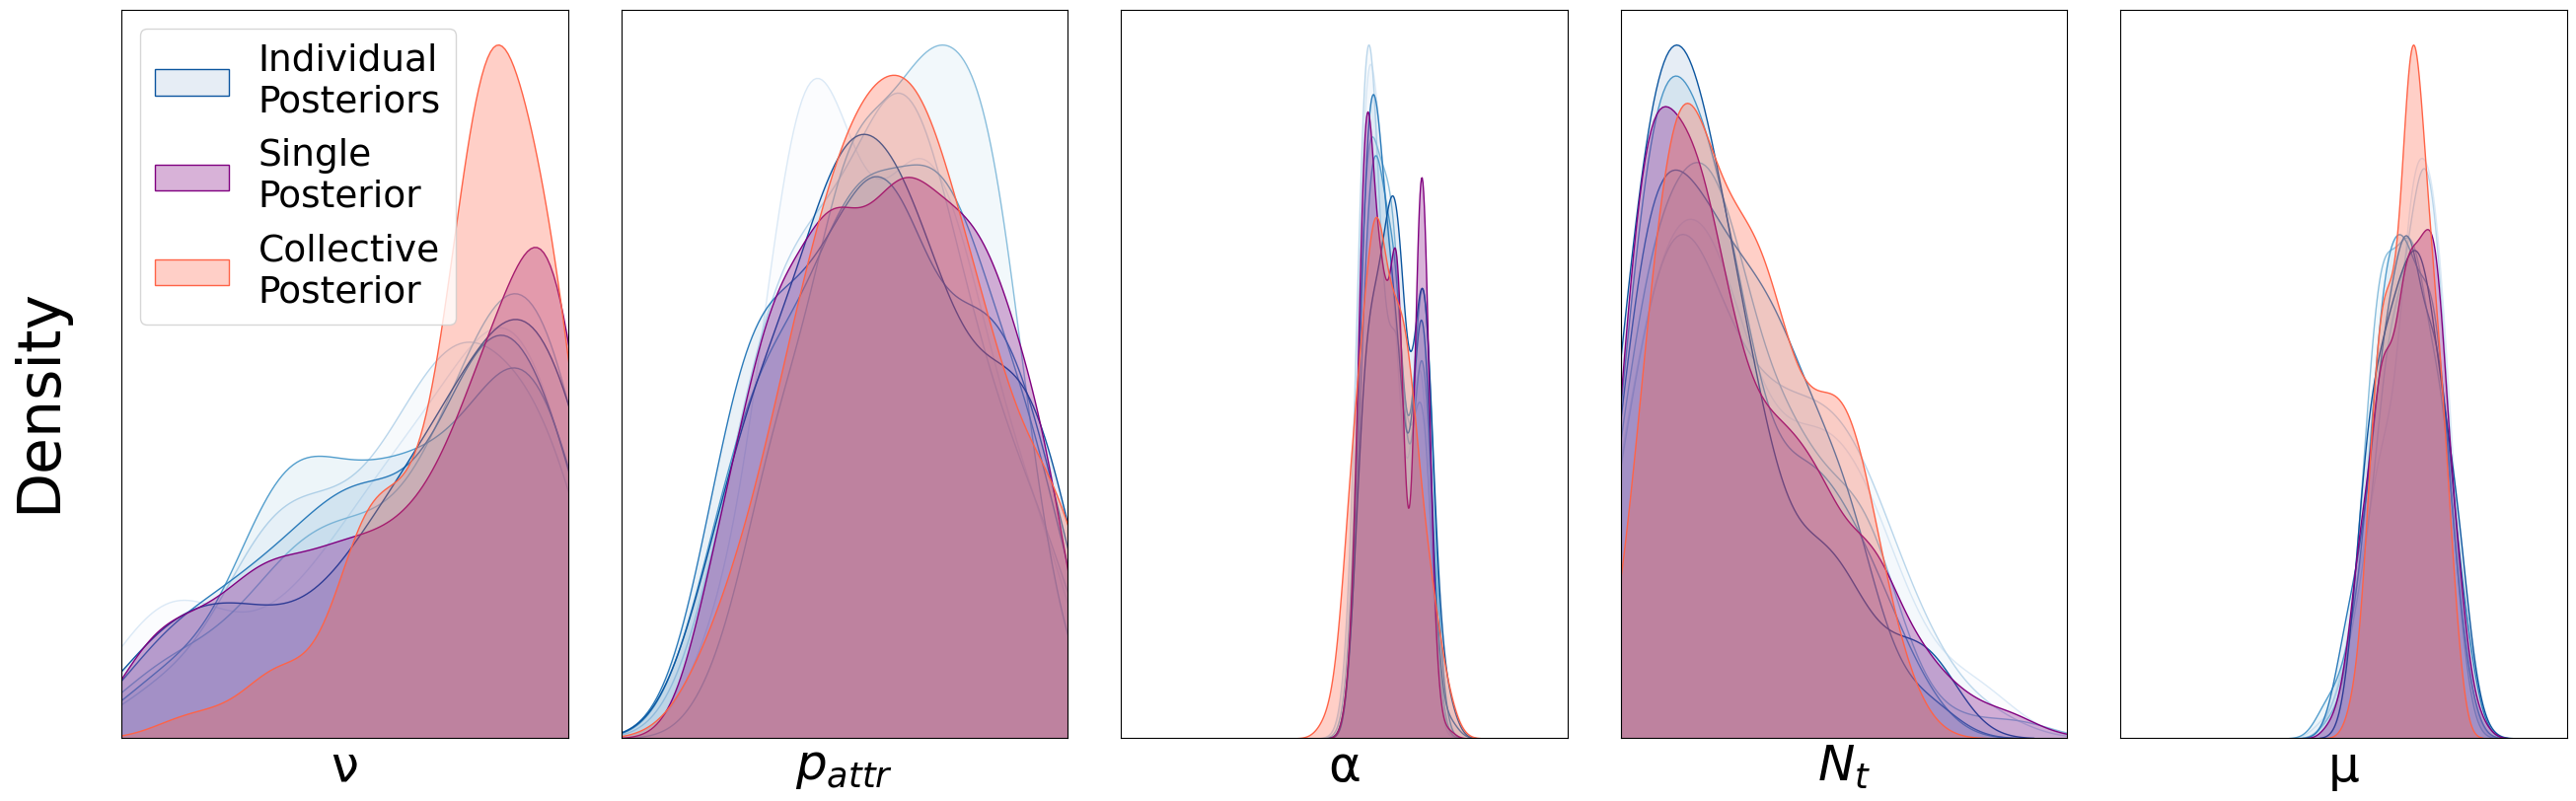

In [6]:
change_font(36)
fig, ax = plt.subplots(1,5, figsize=(27,9), tight_layout=True)
labels = ['ν', '$p_{attr}$', 'α', '$N_t$', 'μ']
# samps = cp.adaptive_sir(n_draws=100_000, n_final=10_000, ess_min_frac = 1e-2)
samps = cp.adaptive_sir(n_draws=100_000, n_final=100, oversample=1.0)
params_df = results_df.iloc[:,6:11]
for n in range(5):
    ax[n].set_xlim(prior.base_dist.low[n], prior.base_dist.high[n])
    
    for i in range(6):
        df_pop = results_df.iloc[:,12+10*i:22+10*i]
        df_pop.loc[:,'dist'] = (df_pop.iloc[:,-10:]**2).sum(1)
        eps = df_pop['dist'].quantile(0.1)
        df_pop = df_pop[df_pop['dist']<eps]
        k = params_df.iloc[df_pop.index, :]
        r = torch.tensor(np.array(k))
        kdeplot(r[:,n], fill=True, alpha=0.1, ax=ax[n], color = p[i], label = 'Individual\nPosteriors' if i==5 and n==0 else '')
    
    y = params_df.iloc[:,n]
    kdeplot(y, fill=True, color='purple', alpha=0.3, label = 'Single\nPosterior' if n==0 else '', ax=ax[n])
    
    kdeplot(samps[:,n], color='tomato', label = 'Collective\nPosterior' if n==0 else '', fill=True, alpha=0.3, ax=ax[n])


    if n in [2,4]:
        minmin = min(samps[:,n].min().item(), r[:,n].min(), y.min())
        maxmax = max(samps[:,n].max().item(), r[:,n].max(), y.max())
        ax[n].set_xlim(minmin, maxmax)
        
    ax[n].set_xlabel(labels[n])
    ax[n].set_yticks([])
    ax[n].set_xticks([])
    ax[n].set_ylabel('')
    ax[n].set_xlim(prior.base_dist.low[n], prior.base_dist.high[n])
    if n != 1:
        ax[n].set_xticklabels([round(torch.e**float(a),3) for a in ax[n].get_xticks()])
fig.supylabel('Density')

ax[0].legend(loc='upper left', fontsize=27)


## Deterministic Sum Of Individual KDE Log-Probabilities

This diagnostic evaluates the deterministic quantity `sum_i log p_i(theta)` directly from the fitted individual KDEs on a Cartesian grid over the prior bounds.
It also repeats the evaluation once and reports the maximum absolute difference, to verify that the KDE log-probability calculation is deterministic on fixed inputs.


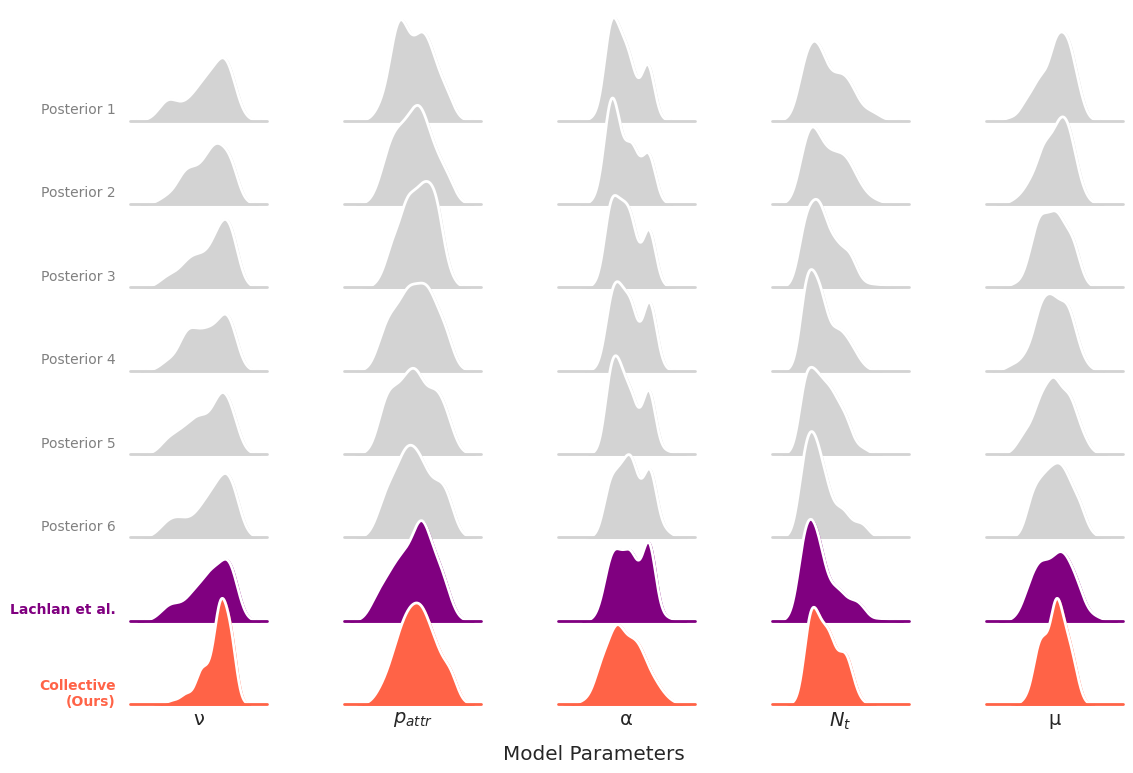

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df = pd.DataFrame(index = range(800), columns = total_sims.columns, dtype=float)
avg_df = params_df[:100]


df.iloc[-len(samps):,:] = samps[:100].numpy()
df.iloc[:len(total_sims),:] = total_sims
df.iloc[len(total_sims):len(total_sims)+len(avg_df),:] = avg_df

g = np.repeat(list("ABCDEFGH"), 100)
df.loc[:, 'g'] = g

unique_chars = sorted(df['g'].unique())
name_map = {}
for char in unique_chars:
    if char == 'G':
        name_map[char] = "Lachlan et al."
    elif char == 'H':
        name_map[char] = "Collective\n(Ours)"
    else:
        # Calculate index (A=1, B=2, etc.)
        idx = ord(char) - ord('A') + 1
        name_map[char] = f"Posterior {idx}"

# Apply the mapping to the dataframe
df['g'] = df['g'].map(name_map)
# --------------------------------------

# --- 2. Data Prep for Plotting ---
# Define row_order using the NEW names in the dataframe
row_order = [f"Posterior {i+1}" for i in range(len(unique_chars) - 2)]
row_order += ["Lachlan et al.", "Collective\n(Ours)"]

# Define Palette
palette = {k: "lightgrey" for k in row_order}
palette["Lachlan et al."] = "purple" # Changed to standard blue/red for visibility
palette["Collective\n(Ours)"] = "tomato"

# Melt (Wide -> Long)
param_cols = [c for c in df.columns if c != "g"]
df_melted = df.melt(id_vars="g", value_vars=param_cols, 
                    var_name="Parameter", value_name="Value")

# --- 3. Setup Plot ---
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df_melted, row="g", col="Parameter", hue="g", 
                  row_order=row_order, hue_order=row_order,
                  aspect=2.2, height=1.0, palette=palette, 
                  sharex='col', sharey='col')
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
# --- 3. Draw Densities ---
# Main density
g.map(sns.kdeplot, "Value",
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)



g.map(sns.kdeplot, "Value", clip_on=False, color="w", lw=2, bw_adjust=1)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# --- 5. Styling ---
g.figure.subplots_adjust(hspace=-0.25) # Adjust overlap
g.figure.supxlabel('Model Parameters')
g.set_titles("") 
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Loop to fix labels and axes
for i, row_axes in enumerate(g.axes):
    for j, ax in enumerate(row_axes):
        
        # Titles (Top Row)
        # if i == 0:
        #     ax.set_title(param_cols[j], fontweight="bold", fontsize=14, pad=20)
            
        # Row Labels (Left Column)
        if j == 0:
            label_text = row_order[i]
            fontweight = "bold" if label_text in ["Lachlan et al.", "Collective\n(Ours)"] else "normal"
            color = palette[label_text] if label_text in ["Lachlan et al.", "Collective\n(Ours)"] else "gray"
            # Adjusted position slightly
            ax.text(-0.1, 0.1, label_text, fontweight=fontweight, color=color,
                    ha="right", va="center", transform=ax.transAxes, fontsize=10)

        # X-Limits (Assuming 'prior' exists in your actual code)
        try:
            # low = prior.base_dist.low[j]
            # high = prior.base_dist.high[j]
            # ax.set_xlim(low, high)
            pass
        except:
            pass 

        # Clean X-Ticks (Bottom Row Only)
        if i == len(row_order) - 1:
            ticks = ax.get_xticks()
            # If you have specific limits, filter ticks here. 
            # Otherwise just formatting:
            ax.set_xticklabels([f"{np.e**t:.3g}" for t in ticks], rotation=45)
        else:
            ax.set_xticks([])
            ax.set_xlabel("")

# Specific Axis Labels
labels = ['ν', '$p_{attr}$', 'α', '$N_t$', 'μ']
# Ensure we don't go out of bounds if params count differs
for i in range(min(len(g.axes[-1]), len(labels))):
    g.axes[-1][i].set_xlabel(labels[i], fontsize=14)

# save
plt.savefig("collective_sparrows_plot_ridge_2d.png", dpi=500)
plt.savefig("collective_sparrows_plot_ridge_2d.tif", dpi=500)
plt.savefig("collective_sparrows_plot_ridge_2d.pdf", dpi=500)

plt.show()